PART A - Data Preparation 

In [1]:
import pandas as pd

#Loading dataset
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

#shape
print("sentiment shape:", sentiment.shape)
print("trades shape:", trades.shape)

display(sentiment.head())
display(trades.head())

sentiment shape: (2644, 4)
trades shape: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [2]:
#missing values
print(sentiment.isnull().sum())
print(trades.isnull().sum())

#duplicates
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

# There seems to be no problem in the dataset provided, so we continue

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
0
0


In [3]:
#timestamp to date and merging
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M")
trades["trade_date"] = trades["Timestamp IST"].dt.date

sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

df = trades.merge(sentiment, left_on="trade_date", right_on="date", how="left")

In [7]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [9]:
#Seeing many columns repeating, dropping the excess columns like timestamp IST and trade_date is enough
# Drop columns like date(came from merge),2 timestamps as it's same or not that useful
df = df.drop(columns=["Timestamp","timestamp","date"])

#also drop columns that is useful but not required for this data analysis 
df = df.drop(columns=["Direction","Transaction Hash","Fee",'Trade ID','Order ID','Crossed','Start Position'])

In [11]:
df.isnull().sum()

Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
Side               0
Timestamp IST      0
Closed PnL         0
trade_date         0
value              6
classification     6
dtype: int64

In [13]:
df[df["classification"].isnull()]

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Closed PnL,trade_date,value,classification
727,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.8330,10000.00,28330.00,BUY,2024-10-26 04:44:00,11655.000000,2024-10-26,NaN,NaN
728,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.7110,10797.51,29272.05,BUY,2024-10-26 04:52:00,13901.794130,2024-10-26,NaN,NaN
729,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,6908.33,17884.98,BUY,2024-10-26 04:52:00,9737.981968,2024-10-26,NaN,NaN
730,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,529.39,1370.54,BUY,2024-10-26 04:52:00,746.228144,2024-10-26,NaN,NaN
731,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,38.65,100.06,BUY,2024-10-26 04:52:00,54.481040,2024-10-26,NaN,NaN
732,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,4523.63,11711.23,BUY,2024-10-26 04:53:00,6376.508848,2024-10-26,NaN,NaN


In [15]:
#Here the only data missing is for 2024-10-26. 
#Seeing the trend that it was almost constant for all days from 16-10-2024 to 29-10-2024 around 69-72 Greed.   
#So we take the value Greed and the average of three days back and forth from 26 ie 23 to 29.

In [17]:
from datetime import date
sentiment[(sentiment["date"] >= date(2024, 10, 15)) &
    (sentiment["date"] <= date(2024, 11, 1))]

,timestamp,value,classification,date
2445,1728970200,65,Greed,2024-10-15
2446,1729056600,73,Greed,2024-10-16
2447,1729143000,71,Greed,2024-10-17
2448,1729229400,73,Greed,2024-10-18
2449,1729315800,72,Greed,2024-10-19
2450,1729402200,73,Greed,2024-10-20
2451,1729488600,72,Greed,2024-10-21
2452,1729575000,70,Greed,2024-10-22
2453,1729661400,71,Greed,2024-10-23
2454,1729747800,69,Greed,2024-10-24


In [19]:
#value which we are going to use for 26-10-2024
avg_value = sentiment[(sentiment["date"] >= date(2024, 10, 23)) & 
                    (sentiment["date"] <= date(2024, 10, 29))]["value"].mean()
print(avg_value)

df.loc[df["trade_date"] == date(2024,10,26),["value","classification"]] = [avg_value,"Greed"]
df.loc[df["trade_date"] == date(2024,10,26)]

71.66666666666667


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Closed PnL,trade_date,value,classification
727,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.8330,10000.00,28330.00,BUY,2024-10-26 04:44:00,11655.000000,2024-10-26,71.666667,Greed
728,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.7110,10797.51,29272.05,BUY,2024-10-26 04:52:00,13901.794130,2024-10-26,71.666667,Greed
729,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,6908.33,17884.98,BUY,2024-10-26 04:52:00,9737.981968,2024-10-26,71.666667,Greed
730,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,529.39,1370.54,BUY,2024-10-26 04:52:00,746.228144,2024-10-26,71.666667,Greed
731,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,38.65,100.06,BUY,2024-10-26 04:52:00,54.481040,2024-10-26,71.666667,Greed
732,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,4523.63,11711.23,BUY,2024-10-26 04:53:00,6376.508848,2024-10-26,71.666667,Greed


In [21]:
df.isnull().sum()

# the data cleaning is done here

Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
Side               0
Timestamp IST      0
Closed PnL         0
trade_date         0
value              0
classification     0
dtype: int64

In [25]:
#creating the required key metrics

daily_trader = df.groupby(["trade_date","Account"]).agg(daily_PnL_per_acc=("Closed PnL", "sum"),
                                                       win_rate=("Closed PnL", lambda x: (x > 0).mean()),
                                                        avg_trade_size=("Size USD", "mean"),
                                                        trades_per_day=("Size Tokens", "sum"),
                                                        daily_total_leverage=("Size USD", "sum"),
                                                        long_trades=("Side", lambda x: (x == "BUY").sum()),
                                                        short_trades=("Side", lambda x: (x == "SELL").sum())
                                                        ).reset_index()
daily_trader["long_short_ratio"] = (daily_trader["long_trades"]/daily_trader["short_trades"].replace(0, 1))
daily_trader = daily_trader.merge(sentiment[["date","classification","value"]],left_on="trade_date",
    right_on="date",how="left").drop(columns=["date"])
daily_trader.head()

,trade_date,Account,daily_PnL_per_acc,win_rate,avg_trade_size,trades_per_day,daily_total_leverage,long_trades,short_trades,long_short_ratio,classification,value
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,159.000000,0.25130,477.00,3,0,3.000000,Greed,63.0
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5556.203333,11.80901,50005.83,7,2,3.500000,Extreme Greed,75.0
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,0.363636,10291.213636,4092.28901,113203.35,5,6,0.833333,Greed,72.0
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,0.000000,5304.975000,3558.00000,10609.95,2,0,2.000000,Greed,70.0
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5116.256667,39897.00000,15348.77,3,0,3.000000,Greed,67.0


PART B - Analysis

,classification,daily_PnL_per_acc,win_rate
0,Extreme Fear,4619.439053,0.329659
1,Fear,5328.818161,0.364033
2,Neutral,3438.618818,0.355414
3,Greed,3318.100730,0.343559
4,Extreme Greed,5161.922644,0.386387


(0.0, 70.0)

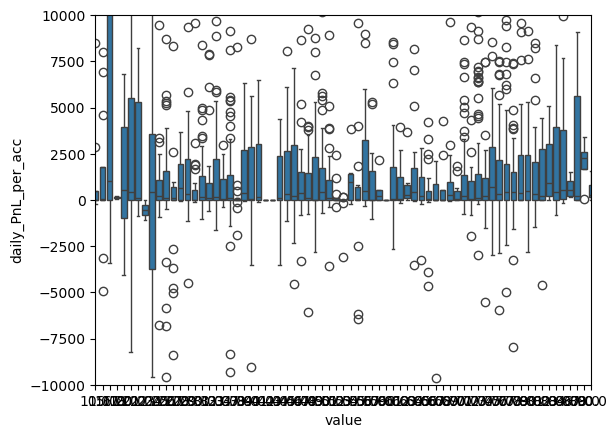

In [30]:
#Question 1
#Does performance (PnL, win rate) differ between Fear vs Greed days?
import seaborn as sns
import matplotlib.pyplot as plt

behavior_summary = daily_trader.groupby("classification")[[
    "daily_PnL_per_acc",
    "win_rate"
]].mean()
order = ['Extreme Fear', 'Fear', 'Neutral', "Greed", 'Extreme Greed']
behavior_summary = behavior_summary.reindex(order).reset_index()
display(behavior_summary)

sns.boxplot(x="value", y="daily_PnL_per_acc", data=daily_trader)
plt.ylim(-10000,10000)
plt.xlim(0,70)

(-500.0, 4000.0)

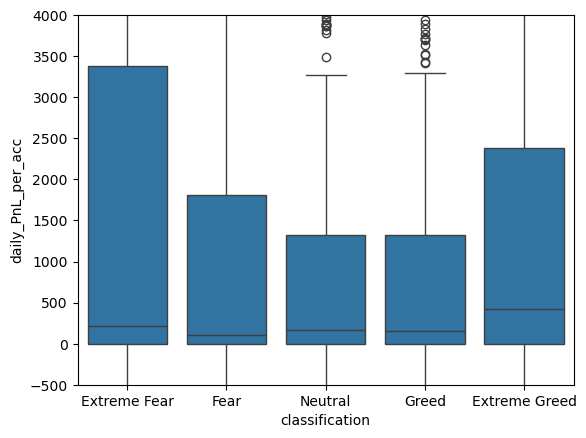

In [32]:
sns.boxplot(x="classification", y="daily_PnL_per_acc", data=daily_trader,order=["Extreme Fear","Fear",
                                                                                "Neutral","Greed","Extreme Greed"])
plt.ylim(-500,4000)

#Inference
#In terms of Daily PnL per trader, fear and extreme fear days show higher average returns. 
#Extreme Greed is also strong and also same as fear and extreme fear days.
#Extreme Greed and Extreme Fear have high variance also,among which Extreme fear have higher variance than Greed


(-0.1, 1.1)

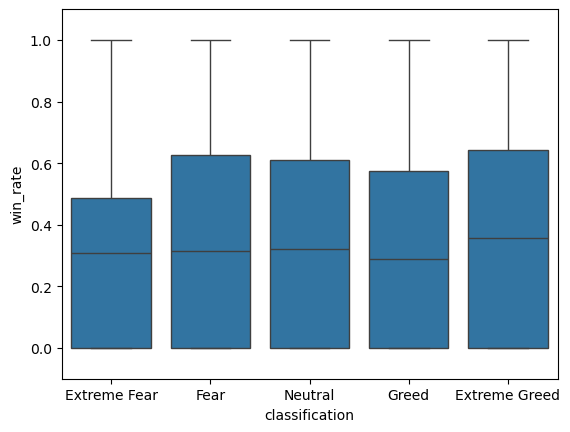

In [34]:
sns.boxplot(x="classification", y="win_rate", data=daily_trader,order=["Extreme Fear","Fear",
                                                                                "Neutral","Greed","Extreme Greed"])
plt.ylim(-0.1,1.1)

(-0.1, 1.2)

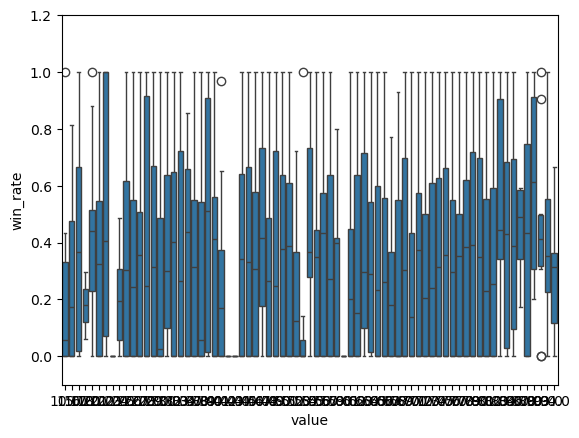

In [36]:
sns.boxplot(x="value", y="win_rate", data=daily_trader)
plt.ylim(-0.1,1.2)

#Inference
#In terms of win rate we can't say anything much, because it shows similar mean and median across all the days.
#We can say in extreme Greed day, the win rate is slightly greater than on other days. But very slightly

In [38]:
#Inference Summary
#In terms of Daily PnL per trader, fear and extreme fear days show higher average returns. 
#Extreme Greed is also strong and also same as fear and extreme fear days.
#Extreme Greed and Extreme Fear have high variance also,among which Extreme fear have higher variance than Greed

#In terms of win rate we can't say anything much, because it shows similar mean and median across all the days.
#We can say in extreme Greed day, the win rate is slightly greater than on other days. But very slightly

In [40]:
#Question 2
#Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
behavior_summary = daily_trader.groupby("classification")[[
    "trades_per_day",
    "avg_trade_size",
    "daily_total_leverage",
    "long_short_ratio"
]].mean()
order = ['Extreme Fear', 'Fear', 'Neutral', "Greed", 'Extreme Greed']
behavior_summary = behavior_summary.reindex(order).reset_index()
behavior_summary

,classification,trades_per_day,avg_trade_size,daily_total_leverage,long_short_ratio
0,Extreme Fear,224150.731403,6773.464125,715526.634000,12.923375
1,Fear,293739.672687,8975.928546,767182.206016,7.223640
2,Neutral,439339.450382,6963.694861,479367.189043,6.450631
3,Greed,366041.870508,6427.866594,445343.356049,5.774688
4,Extreme Greed,671532.263342,5371.637182,236625.788156,5.669434


(-800.0, 70000.0)

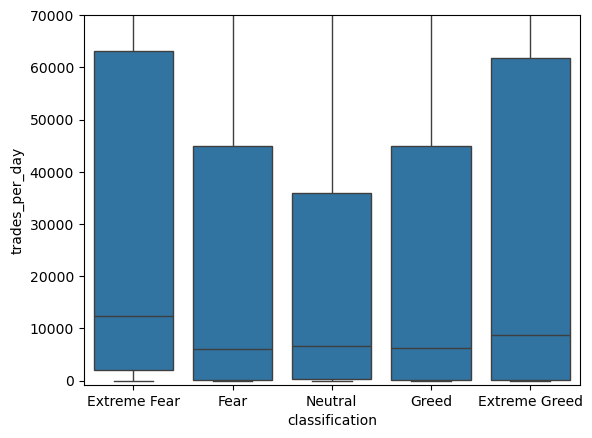

In [42]:
sns.boxplot(x="classification", y="trades_per_day", data=daily_trader,order=["Extreme Fear","Fear",
                                                                                "Neutral","Greed","Extreme Greed"])
plt.ylim(-800,70000)

#Inference
#In terms of trades per day, Extreme fear and fear clearly have higher mean median and the upper tail.
#Whereas the Greed and Extreme Greed show lower mean and also wider distribution in comparison to fear days
#This is becz traders, trade in market more number of times when feared whereas in greed they try to hold for more profit.
#leading to less no of trades 

(-100.0, 10000.0)

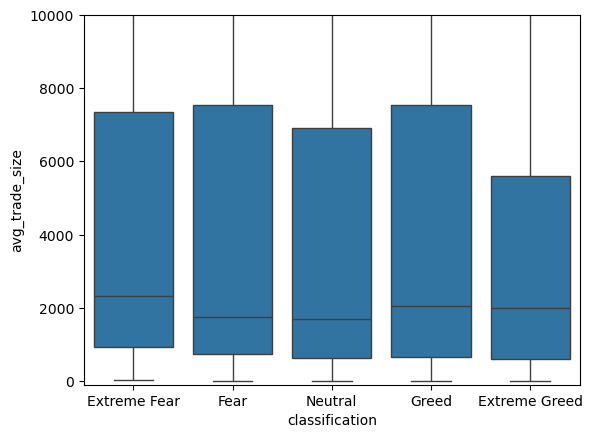

In [44]:
sns.boxplot(x="classification", y="avg_trade_size", data=daily_trader,order=["Extreme Fear","Fear",
                                                                                "Neutral","Greed","Extreme Greed"])
plt.ylim(-100,10000)

#Inference
#In terms of trade size, the fear day has a higher mean and upper tail, maybe a large size is brought to make huge 
# profit or reduce the loss, whereas extreme greed shows the lowest trading size and also have lowest variance
#So traders do not increase the order size during greed, the trade size is higher during fear

(-100.0, 400000.0)

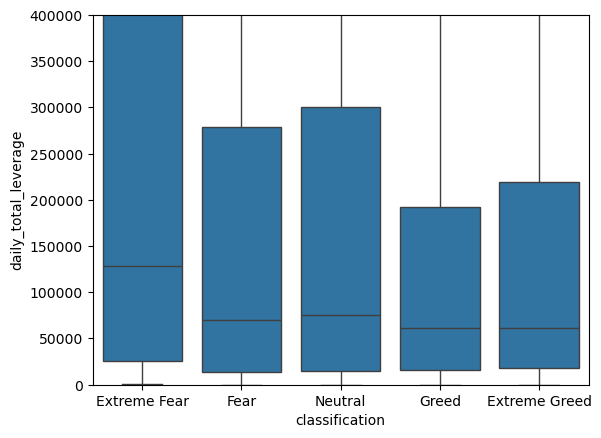

In [46]:
sns.boxplot(x="classification", y="daily_total_leverage", data=daily_trader,order=["Extreme Fear","Fear",
                                                                                "Neutral","Greed","Extreme Greed"])
plt.ylim(-100,400000)

#Inference
#Total leverage is very easily seen, the fear regime shows much larger leverage exposure whereas greed regime
# shows significantly lower leverage. Extreme greed shows much more lower leverage.
#Traders increase leverage during fear to defend their losses or reactive for the profits rather than taking the optimistic expansion

(-0.5, 4.0)

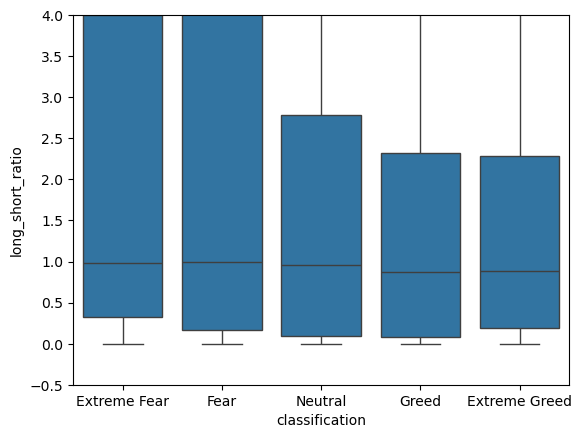

In [48]:
sns.boxplot(x="classification", y="long_short_ratio", data=daily_trader,order=["Extreme Fear","Fear",
                                                                                "Neutral","Greed","Extreme Greed"])
plt.ylim(-0.5,4)

#Inference
#In extreme fear days the long is refered as the trader is scared of the present, whereas the greed days the
#trader wants to go with short and earn faster. So in fear days the long short ratio is higher whereas 
#greed and extreme greed show lower ratio as short value is more.

In [50]:
#Inference Summary Combined

#In terms of trades per day, Extreme fear and fear clearly have a higher mean, median and the upper tail.
#Whereas the Greed and Extreme Greed show a lower mean and also a wider distribution in comparison to fear days
#This is because traders trade in the market more number of times when fearful, whereas in greed they try to hold for more profit.
#leading to fewer trades 

##In terms of trade size, the fear day has a higher mean and upper tail, maybe a large size is brought to make huge 
# profit or reduce the loss, whereas extreme greed shows the lowest trading size and also have lowest variance
#So traders do not increase the order size during greed, the trade size is larger during fear

#Total leverage is very easily seen, the fear regime shows much larger leverage exposure, whereas the greed regime
# shows significantly lower leverage. Extreme greed shows much lower leverage.
#Traders increase leverage during fear to defend their losses or reactive for the profits rather than taking the optimistic expansion

#In extreme fear days, the long is refered as the trader is scared of the present, whereas in greed days the
#trader wants to go with short and earn faster. So in fear days the long short ratio is higher, whereas 
#greed and extreme greed show a lower ratio as the short value is more.

In [52]:
#Segmentation

In [54]:
#High Risk vs Low Risk

trader_risk = daily_trader.groupby("Account")["daily_total_leverage"].mean()
threshold = trader_risk.median()

daily_trader["risk_group"] = daily_trader["Account"].map(
    lambda x: "High Risk" if trader_risk[x] > threshold else "Low Risk")
daily_trader.groupby(["classification","risk_group"])["daily_PnL_per_acc"].mean()

#High Risk Traders outperfom in all the days. The best performance is on fear days.
#the only day when low risk benefits more than high risk is Extreme greed days.

#So when the market is scared, risk taker will dominate the profits earnings, during extreme greed, low risk outperfoms.

classification  risk_group
Extreme Fear    High Risk     7497.439636
                Low Risk      2015.533763
Extreme Greed   High Risk     3931.306079
                Low Risk      5875.162875
Fear            High Risk     9583.990381
                Low Risk      1699.406562
Greed           High Risk     5677.204379
                Low Risk      1893.295556
Neutral         High Risk     4103.741143
                Low Risk      2961.795964
Name: daily_PnL_per_acc, dtype: float64

In [56]:
#Frequent vs Infrequent Traders

trader_freq = daily_trader.groupby("Account")["trades_per_day"].mean()
threshold = trader_freq.median()

daily_trader["freq_group"] = daily_trader["Account"].map(
    lambda x: "Frequent" if trader_freq[x] > threshold else "Infrequent")
daily_trader.groupby(["classification","freq_group"])["daily_PnL_per_acc"].mean()

#Frequent traders trade much more than infrequent ones on all days, but that's obvious because comparing with the median
# The frequent traders' behaviour changes with sentiment, the earnings decrease moving from fear to greed.
#The extreme fear has the highest and extreme greed has the lowest PnL.

#So when the market is scared, more activities take place, whereas no of activities decreases when the market calms down

classification  freq_group
Extreme Fear    Frequent      3889.040424
                Infrequent    5686.944741
Extreme Greed   Frequent      6386.669614
                Infrequent    3536.152330
Fear            Frequent      4451.552261
                Infrequent    6418.376166
Greed           Frequent      2240.044303
                Infrequent    4726.096135
Neutral         Frequent      3022.158713
                Infrequent    3948.720840
Name: daily_PnL_per_acc, dtype: float64

In [58]:
#Long Term vs Short Term Traders

trader_term = daily_trader.groupby("Account")["long_short_ratio"].mean()
threshold = trader_term.median()

daily_trader["term"] = daily_trader["Account"].map(
    lambda x: "Long Term" if trader_term[x] > threshold else "Short Term")
daily_trader.groupby(["classification","term"])["daily_PnL_per_acc"].mean()

#Long term trader make much more than short term ones on all days
# The long term traders' behaviour changes with sentiment, the long-term profit decreases moving from fear to greed.
#The extreme fear has the highest and greed has the lowest frequency. Unexpextedly the extreme greed also have good earnings

#So when the market is scared, long term is more profitable. long term is better for both extreme situations like extreme greed also

classification  term      
Extreme Fear    Long Term     10901.080597
                Short Term    -1355.780952
Extreme Greed   Long Term      6886.742952
                Short Term     3950.641068
Fear            Long Term      9186.336008
                Short Term     1218.348325
Greed           Long Term      4760.943534
                Short Term     1580.800210
Neutral         Long Term      5859.309652
                Short Term      912.680557
Name: daily_PnL_per_acc, dtype: float64

In [60]:
#Insights
# 1 Fear drives the Trading activities. As the number of trades seems more during scared market with high median and 
#    mean of trades. These activities dramatically decrease as the market calms down or greed increases in the market.
#
# 2. High leverage exposure/ High risk is seen when the market is scared. The value almost halves when 
#    market shifts from fear to greed. During the fear time, the high-risk takers make the most profits
#    out of the market. Even though high risk taker make more earning in all types of days except 
#    during extreme greed, as in this market, low risk is more profitable.
#
# 3. The long term is best for both extreme cases. Still, long-term is preferred more for times when the market is 
#    scared or in an extreme fear situation. Whereas in greed and neutral situation, some start to shift to short-term also.
#

In [62]:
#Based on the findings
#
#If Sentiment = Fear or Extreme Fear:
#    The number of trading activities increases
#    Leverage Spikes during fear
#    Risk exposure is highest
#    High-risk traders outperforms but variance is likely higher
#    Long-term is preferred more
#
#If Sentiment = Greed or Extreme Greed:
#    Risk exposure is lower in comparison
#    Fewer trades happening
#    Short-term is preferred for extreme greed
#    